In [3]:
from  langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal,Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage
from dotenv import load_dotenv
from pydantic import BaseModel ,Field
import operator

In [ ]:
load_dotenv()

In [4]:
# while selecting model we should on the basis of use case but here just for learning we are choosing randomly
generator_llm=ChatOpenAI(model='gpt-4o')
evaluator_llm=ChatOpenAI(model='gpt-4o-mini')
optimizer_llm=ChatOpenAI(model='gpt-40')

In [5]:
class tweetEvaluation(BaseModel):
    evaluation : Literal["approved","needs_improvement"] =Field(...,description="final evaluation result")
    feedback:str=Field(...,description="feedback for the tweet")


In [6]:
structured_evaluator = evaluator_llm.with_structured_output(tweetEvaluation)

In [52]:
class tweet_state (TypedDict):
    topic :str
    tweet :str
    evaluation: Literal["approved","needs_improvement"]
    feedback:str
    iteration:int
    max_iteration:int

    tweet_history:Annotated[list[str],operator.add] 
    feedback_history:Annotated[list[str],operator.add]


In [43]:
def generate_tweet (state:tweet_state):
    #prompt
    messages =[
        SystemMessage(content="you are a funny and clever twitter/X influencer."),
        HumanMessage(content=f"""
                     write a short orignal , and hilarious tweet on the topic : "{state['topic']}".
                     rules :
                     do not use question answer format.
                     max 280 characters.
                     use observational humor, irony, sarcasm, or cultural refrences.
                     think in meme logic, punchline or relatable takes.
                     use simple,day to day english""" 
                     )
        ]
    response= generator_llm.invoke(messages).content

    return {'tweet':response,'tweet_history':[response]}

In [44]:
def evaluate_tweet(state:tweet_state):
    # prompt
    messages =[
        SystemMessage(content="you are a ruthless, no-laugh-given twitter critic.You evaluatetweets based on humor , originality , virality , and tweet format."),
        HumanMessage(content=f"""
                     evaluate the following tweet:
                     tweet : "{state['tweet']}" 
                     use the criteria below to evaluate the tweet :
                     1.originality : is this fresh?
                     2.humor:did it genuinely make you laugh?
                     3.punchiness: is it short,sharp and scroll stopping?
                     4.virality potential : would people retweet or share it?
                     5.format : is it a well formed tweet 
                     
                     auto reject if 
                     if it is written in question ans format 
                     if it exceeds 280 characters 
                     if reads like a tradional setup punchline joke 
                     if it ends with generic, throwaway or deflating lines that weaken the humor )


                     respond only in structured format:
                     evaluation : "approved" or "needs_improvement"
                     feedback: one paragraph explaining the strengths and weaknesses
                     """)

    ]

    response= structured_evaluator.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback,'feedback_history' :[response.feedback] }
    


In [45]:
def optimize_tweet(state:tweet_state):
    messages =[
        SystemMessage(content="you punch tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
                     Improve the tweet baised on this feedback:
                      "{state['feedback']}"
                      topic : "{state['topic']}"
                      original tweet : {state['tweet']}
                    re write it a s short, viral-worthy tweet. avaoid Q&A style and stay under 280 characters.
                     """)
                
        ]
    response= optimizer_llm.invoke(messages).content
    iteration = state['iteration']+1

    return {'tweet':response, 'iteration':iteration}


In [50]:
def route_evaluation (state:tweet_state):
    if state['evaluation']=='approved' or state['iteration']>=state['max_iteration']:
        return 'approved'
        #return END
    else :
        return 'needs_improvement'
        #return'optimize'
    

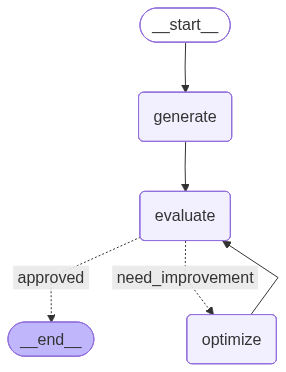

In [51]:
graph=StateGraph(tweet_state)

graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimize',optimize_tweet)


graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'approved':END, 'need_improvement':'optimize'})
#graph.add_conditional_edges('evaluate',route_evaluation)
graph.add_edge('optimize','evaluate')


workflow=graph.compile()
workflow


In [53]:
initial_state={
    "topic":"Egdbeq",
    "iteration":1,
    "max_iteration": 5
}
result=workflow.invoke(initial_state)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
for tweet in result('tweet_history'):
    print(tweet)